In [24]:
import os
os.system("open animation_se3.gif")

0

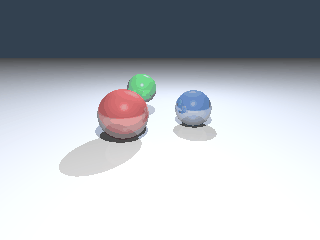

In [22]:
from IPython.display import Image, display
display(Image("animation_se3.gif", width=500))

In [1]:
import sys
!{sys.executable} -m pip install scipy

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from scipy.linalg import expm, logm
from scipy.spatial.transform import Rotation as Rot
from IPython.display import Image as IPImage, display

In [3]:
EPS = 1e-5
INF = 1e9

os.makedirs("frames_se3", exist_ok=True)
os.makedirs("frames_euclidean", exist_ok=True)
os.makedirs("report_assets", exist_ok=True)

In [4]:
def make_pose(R, t):
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T


def pose_R(T):
    return T[:3, :3]


def pose_t(T):
    return T[:3, 3]


def look_at(camera_pos, target, up_hint=np.array([0, 1, 0])):
    camera_pos = np.array(camera_pos, dtype=float)
    target = np.array(target, dtype=float)

    forward = target - camera_pos
    forward = forward / np.linalg.norm(forward)

    right = np.cross(up_hint, forward)
    right = right / np.linalg.norm(right)

    up = np.cross(forward, right)
    up = up / np.linalg.norm(up)

    R = np.column_stack([right, up, forward])
    return make_pose(R, camera_pos)

In [5]:
def se3_interpolate(T1, T2, alpha):
    """
    Lie-group interpolation on SE(3).
    T(alpha) = T1 * exp(alpha * log(inv(T1) * T2))
    """
    relative_motion = np.linalg.inv(T1) @ T2
    twist_matrix = logm(relative_motion)
    T_alpha = T1 @ expm(alpha * twist_matrix)

    T_alpha = np.real_if_close(T_alpha)
    T_alpha[3, :] = np.array([0, 0, 0, 1])

    return T_alpha


def so3_interpolate(R1, R2, alpha):
    """
    Rotation interpolation using scipy Rotation.
    """
    r1 = Rot.from_matrix(R1)
    r2 = Rot.from_matrix(R2)

    relative = r1.inv() * r2
    rotvec = relative.as_rotvec()

    result = r1 * Rot.from_rotvec(alpha * rotvec)
    return result.as_matrix()


def se3_interpolate_euclidean(T1, T2, alpha):
    """
    Simpler comparison method:
    SO(3) interpolation for rotation + linear interpolation for translation.
    """
    R = so3_interpolate(pose_R(T1), pose_R(T2), alpha)
    t = (1 - alpha) * pose_t(T1) + alpha * pose_t(T2)

    return make_pose(R, t)

In [6]:
target = np.array([0, 0.3, 0])

keyframes = [
    look_at([-4, 2.2, -5], target),
    look_at([0, 2.0, -6], target),
    look_at([4, 2.4, -4], target),
    look_at([5, 2.0, 1], target),
    look_at([0, 2.7, 5], target),
    look_at([-4, 2.0, 2], target),
]

In [7]:
def build_scene():
    spheres = [
        {
            "center": np.array([-1.3, 0.7, 0.0]),
            "radius": 0.7,
            "color": np.array([0.9, 0.2, 0.2]),
            "reflect": 0.25
        },
        {
            "center": np.array([1.1, 0.6, -0.4]),
            "radius": 0.6,
            "color": np.array([0.2, 0.4, 0.9]),
            "reflect": 0.35
        },
        {
            "center": np.array([0.0, 1.2, 1.0]),
            "radius": 0.5,
            "color": np.array([0.2, 0.8, 0.3]),
            "reflect": 0.15
        }
    ]

    planes = [
        {
            "point": np.array([0, 0, 0]),
            "normal": np.array([0, 1, 0]),
            "color": np.array([0.8, 0.8, 0.8]),
            "reflect": 0.1
        }
    ]

    lights = [
        {
            "pos": np.array([-3, 5, -4]),
            "color": np.array([1.0, 1.0, 1.0])
        },
        {
            "pos": np.array([4, 6, 3]),
            "color": np.array([0.7, 0.8, 1.0])
        }
    ]

    return spheres, planes, lights

In [8]:
def intersect_sphere(ro, rd, sphere):
    center = sphere["center"]
    radius = sphere["radius"]

    oc = ro - center
    b = 2.0 * np.dot(rd, oc)
    c = np.dot(oc, oc) - radius * radius
    disc = b * b - 4 * c

    if disc < 0:
        return INF

    sqrt_disc = np.sqrt(disc)

    t1 = (-b - sqrt_disc) / 2
    t2 = (-b + sqrt_disc) / 2

    if t1 > EPS:
        return t1
    if t2 > EPS:
        return t2

    return INF


def intersect_plane(ro, rd, plane):
    point = plane["point"]
    normal = plane["normal"]

    denom = np.dot(rd, normal)

    if abs(denom) < EPS:
        return INF

    t = np.dot(point - ro, normal) / denom

    if t > EPS:
        return t

    return INF


def find_nearest_hit(ro, rd, spheres, planes):
    closest_t = INF
    closest_obj = None
    closest_type = None

    for sphere in spheres:
        t = intersect_sphere(ro, rd, sphere)

        if t < closest_t:
            closest_t = t
            closest_obj = sphere
            closest_type = "sphere"

    for plane in planes:
        t = intersect_plane(ro, rd, plane)

        if t < closest_t:
            closest_t = t
            closest_obj = plane
            closest_type = "plane"

    return closest_t, closest_obj, closest_type

In [9]:
def get_normal(point, obj, obj_type):
    if obj_type == "sphere":
        normal = point - obj["center"]
        return normal / np.linalg.norm(normal)

    if obj_type == "plane":
        return obj["normal"] / np.linalg.norm(obj["normal"])


def trace_ray(ro, rd, spheres, planes, lights, depth=2):
    t, obj, obj_type = find_nearest_hit(ro, rd, spheres, planes)

    if obj is None:
        return np.array([0.03, 0.05, 0.08])

    hit = ro + t * rd
    normal = get_normal(hit, obj, obj_type)

    base_color = obj["color"]
    final_color = 0.08 * base_color

    for light in lights:
        light_dir = light["pos"] - hit
        light_dist = np.linalg.norm(light_dir)
        light_dir = light_dir / light_dist

        shadow_origin = hit + normal * EPS
        shadow_t, shadow_obj, _ = find_nearest_hit(
            shadow_origin,
            light_dir,
            spheres,
            planes
        )

        in_shadow = shadow_t < light_dist

        if not in_shadow:
            diffuse = max(np.dot(normal, light_dir), 0)
            final_color += diffuse * base_color * light["color"]

            view_dir = -rd
            reflect_dir = 2 * np.dot(normal, light_dir) * normal - light_dir
            spec = max(np.dot(view_dir, reflect_dir), 0) ** 32
            final_color += 0.35 * spec * light["color"]

    reflect_amount = obj.get("reflect", 0)

    if depth > 0 and reflect_amount > 0:
        reflect_dir = rd - 2 * np.dot(rd, normal) * normal
        reflect_origin = hit + normal * EPS

        reflected_color = trace_ray(
            reflect_origin,
            reflect_dir,
            spheres,
            planes,
            lights,
            depth - 1
        )

        final_color = (1 - reflect_amount) * final_color + reflect_amount * reflected_color

    return np.clip(final_color, 0, 1)

In [10]:
def render_frame(pose, width=320, height=240, fov_deg=60):
    spheres, planes, lights = build_scene()

    R = pose[:3, :3]
    cam_pos = pose[:3, 3]

    right = R[:, 0]
    up = R[:, 1]
    forward = R[:, 2]

    fov = np.deg2rad(fov_deg)
    aspect = width / height

    h_half = np.tan(fov / 2)
    w_half = h_half * aspect

    image = np.zeros((height, width, 3), dtype=np.float32)

    for y in range(height):
        for x in range(width):
            px = (2 * (x + 0.5) / width - 1) * w_half
            py = (1 - 2 * (y + 0.5) / height) * h_half

            rd = forward + px * right + py * up
            rd = rd / np.linalg.norm(rd)

            color = trace_ray(cam_pos, rd, spheres, planes, lights, depth=2)

            image[y, x] = color

    image = np.clip(image, 0, 1) ** (1 / 2.2)
    return (image * 255).astype(np.uint8)

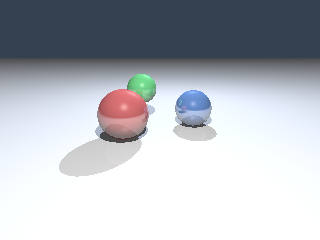

In [11]:
sample = render_frame(keyframes[0], width=320, height=240)

sample_path = "report_assets/sample_frame.png"
imageio.imwrite(sample_path, sample)

display(IPImage(sample_path))

In [12]:
def build_trajectory(keyframes, frames_per_segment=20, method="se3"):
    poses = []

    for i in range(len(keyframes) - 1):
        T1 = keyframes[i]
        T2 = keyframes[i + 1]

        for j in range(frames_per_segment):
            alpha = j / frames_per_segment

            if method == "se3":
                pose = se3_interpolate(T1, T2, alpha)
            else:
                pose = se3_interpolate_euclidean(T1, T2, alpha)

            poses.append(pose)

    poses.append(keyframes[-1])
    return poses


se3_poses = build_trajectory(keyframes, frames_per_segment=18, method="se3")
euc_poses = build_trajectory(keyframes, frames_per_segment=18, method="euclidean")

print("SE(3) frames:", len(se3_poses))
print("Euclidean frames:", len(euc_poses))

SE(3) frames: 91
Euclidean frames: 91


In [13]:
def render_animation(poses, folder, gif_name, width=320, height=240, fps=12):
    frames = []

    for i, pose in enumerate(poses):
        print(f"Rendering frame {i + 1}/{len(poses)}")

        img = render_frame(pose, width=width, height=height)

        frame_path = f"{folder}/frame_{i:03d}.png"
        imageio.imwrite(frame_path, img)

        frames.append(img)

    imageio.mimsave(gif_name, frames, fps=fps)

    print(f"Saved {gif_name}")


render_animation(
    se3_poses,
    folder="frames_se3",
    gif_name="animation_se3.gif",
    width=320,
    height=240,
    fps=12
)

render_animation(
    euc_poses,
    folder="frames_euclidean",
    gif_name="animation_euclidean.gif",
    width=320,
    height=240,
    fps=12
)

Rendering frame 1/91
Rendering frame 2/91
Rendering frame 3/91
Rendering frame 4/91
Rendering frame 5/91
Rendering frame 6/91
Rendering frame 7/91
Rendering frame 8/91
Rendering frame 9/91
Rendering frame 10/91
Rendering frame 11/91
Rendering frame 12/91
Rendering frame 13/91
Rendering frame 14/91
Rendering frame 15/91
Rendering frame 16/91
Rendering frame 17/91
Rendering frame 18/91
Rendering frame 19/91
Rendering frame 20/91
Rendering frame 21/91
Rendering frame 22/91
Rendering frame 23/91
Rendering frame 24/91
Rendering frame 25/91
Rendering frame 26/91
Rendering frame 27/91
Rendering frame 28/91
Rendering frame 29/91
Rendering frame 30/91
Rendering frame 31/91
Rendering frame 32/91
Rendering frame 33/91
Rendering frame 34/91
Rendering frame 35/91
Rendering frame 36/91
Rendering frame 37/91
Rendering frame 38/91
Rendering frame 39/91
Rendering frame 40/91
Rendering frame 41/91
Rendering frame 42/91
Rendering frame 43/91
Rendering frame 44/91
Rendering frame 45/91
Rendering frame 46/

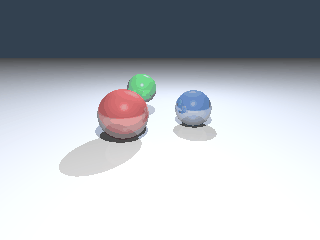

SE(3) Lie-group camera animation


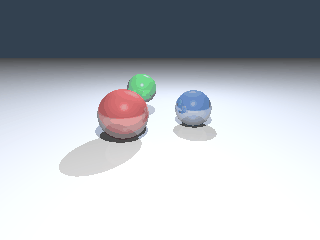

Euclidean comparison animation


In [14]:
display(IPImage("animation_se3.gif", width=480))
print("SE(3) Lie-group camera animation")

display(IPImage("animation_euclidean.gif", width=480))
print("Euclidean comparison animation")

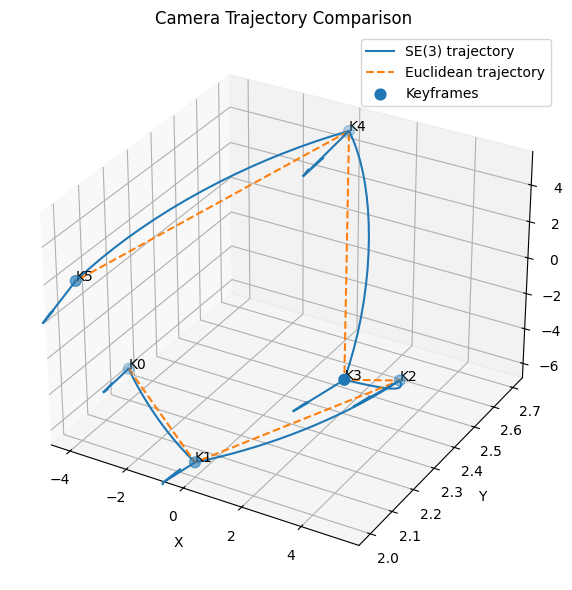

In [15]:
def plot_trajectory(se3_poses, euc_poses, keyframes):
    se3_pts = np.array([pose_t(T) for T in se3_poses])
    euc_pts = np.array([pose_t(T) for T in euc_poses])
    key_pts = np.array([pose_t(T) for T in keyframes])

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(se3_pts[:, 0], se3_pts[:, 1], se3_pts[:, 2], label="SE(3) trajectory")
    ax.plot(euc_pts[:, 0], euc_pts[:, 1], euc_pts[:, 2], "--", label="Euclidean trajectory")
    ax.scatter(key_pts[:, 0], key_pts[:, 1], key_pts[:, 2], s=60, label="Keyframes")

    for i, T in enumerate(keyframes):
        p = pose_t(T)
        R = pose_R(T)

        ax.quiver(p[0], p[1], p[2], R[0, 2], R[1, 2], R[2, 2], length=0.5)

        ax.text(p[0], p[1], p[2], f"K{i}")

    ax.set_title("Camera Trajectory Comparison")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()

    plt.tight_layout()
    plt.savefig("report_assets/camera_trajectory.png", dpi=200)
    plt.show()


plot_trajectory(se3_poses, euc_poses, keyframes)

In [16]:
def path_length(poses):
    pts = np.array([pose_t(T) for T in poses])
    return np.sum(np.linalg.norm(np.diff(pts, axis=0), axis=1))


def max_rotation_det_error(poses):
    errors = []

    for T in poses:
        R = pose_R(T)
        errors.append(abs(np.linalg.det(R) - 1))

    return max(errors)


print("Trajectory comparison:")
print(f"SE(3) path length: {path_length(se3_poses):.4f}")
print(f"Euclidean path length: {path_length(euc_poses):.4f}")

print()
print("Rotation determinant check:")
print(f"SE(3) max det error: {max_rotation_det_error(se3_poses):.2e}")
print(f"Euclidean max det error: {max_rotation_det_error(euc_poses):.2e}")

Trajectory comparison:
SE(3) path length: 26.4358
Euclidean path length: 25.2227

Rotation determinant check:
SE(3) max det error: 1.55e-15
Euclidean max det error: 8.88e-16


In [17]:
report = """
# Ray-Traced Camera Animation Using SE(3) Interpolation

## Overview

##For this assignment, I extended my ray tracing project by adding a moving camera animation.
Instead of moving the camera using only standard Euclidean interpolation, I represented each
camera keyframe as a rigid transformation matrix in SE(3). These transformations store both
the camera rotation and translation in one 4x4 pose matrix.

## Trajectory Construction

I created several camera keyframes around the scene. Each keyframe was generated using a
look-at camera function, where the camera position changes while the camera continues to
face the center of the scene. This gives a smooth orbit-style movement around the objects.

## Lie-Group Interpolation Method

For the main animation, I used SE(3) interpolation. Given two poses T1 and T2, I computed
the relative motion between them:

    inv(T1) @ T2

Then I used the matrix logarithm to map this motion into the tangent space. After scaling
that tangent-space motion by alpha, I mapped it back to SE(3) using the matrix exponential.
The final interpolation formula was:

    T(alpha) = T1 @ exp(alpha * log(inv(T1) @ T2))

This creates motion that stays on the SE(3) manifold and treats rotation and translation as
one rigid-body transformation.

## Euclidean Comparison

I also implemented a simpler comparison method. In that method, the rotation is interpolated
separately and the translation is linearly interpolated between camera positions. This works,
but it separates rotation and translation instead of treating the camera pose as one geometric
object. The SE(3) interpolation gives a more consistent rigid-body camera motion.

## Results and Observations

The final output includes a ray-traced animation from the SE(3) camera trajectory and a
comparison animation using the Euclidean method. I also plotted the camera centers and
keyframes to visualize the path. The SE(3) version produces smooth motion through the
keyframes and keeps each camera pose as a valid rigid transformation.
"""

with open("report.md", "w") as f:
    f.write(report)

print(report)
print("Saved report.md")


# Ray-Traced Camera Animation Using SE(3) Interpolation

## Overview

##For this assignment, I extended my ray tracing project by adding a moving camera animation.
Instead of moving the camera using only standard Euclidean interpolation, I represented each
camera keyframe as a rigid transformation matrix in SE(3). These transformations store both
the camera rotation and translation in one 4x4 pose matrix.

## Trajectory Construction

I created several camera keyframes around the scene. Each keyframe was generated using a
look-at camera function, where the camera position changes while the camera continues to
face the center of the scene. This gives a smooth orbit-style movement around the objects.

## Lie-Group Interpolation Method

For the main animation, I used SE(3) interpolation. Given two poses T1 and T2, I computed
the relative motion between them:

    inv(T1) @ T2

Then I used the matrix logarithm to map this motion into the tangent space. After scaling
that tangent-space moti

In [18]:
files = [
    "animation_se3.gif",
    "animation_euclidean.gif",
    "report_assets/sample_frame.png",
    "report_assets/camera_trajectory.png",
    "report.md"
]

print("Final deliverables check:")
print("-" * 35)

for file in files:
    if os.path.exists(file):
        print(f"✅ {file}")
    else:
        print(f"❌ {file}")

Final deliverables check:
-----------------------------------
✅ animation_se3.gif
✅ animation_euclidean.gif
✅ report_assets/sample_frame.png
✅ report_assets/camera_trajectory.png
✅ report.md


Saved one animation file: animation_se3.gif
